In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
#%matplotlib ipympl

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

def quality_cuts(df):
        """
        Make quality cuts on the APOGEE catalog.
        Parameters
        ----------
        df : pandas.DataFrame

            Full APOGEE catalog
        Returns
        -------
        pandas.DataFrame
        """
        # Limit to main red star sample
        df = df[df['EXTRATARG'] == 0]

        # Weed out bad flags
        fatal_flags = (2**23) # STAR_BAD
        df = df[df['ASPCAPFLAG'] & fatal_flags == 0]
        # Cut low-S/N targets
        df = df[df['SNREV'] > 200]
        # Limit to giants
        df = df[(df['LOGG'] > 1) & (df['LOGG'] < 2) &
                (df['TEFF'] > 3700) & (df['TEFF'] < 4600)]
        # Replace NaN stand-in values with NaN
        df.replace(99.999, np.nan, inplace=True)
        # Limit to stars with measurements of both [Fe/H] and [O/Fe]
        df.dropna(subset=['FE_H', 'O_FE'], inplace=True)
        df.reset_index(inplace=True, drop=True)
        return df

def fits_to_pandas(path, **kwargs):
    """
    Import a table in the form of a FITS file and convert it to a pandas DataFrame.
    Parameters
    ----------
    path : Path or str
    Path to fits file
    Other keyword arguments are passed to astropy.table.Table
    Returns
    -------
    df : pandas DataFrame
    """
    # Read FITS file into astropy table
    table = Table.read(path, format='fits', **kwargs)
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    # Convert byte-strings to ordinary strings and convert to pandas
    df = decode(table[cols].to_pandas())
    return df

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    Parameters
    ----------
    df : pandas DataFrame
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

data = fits_to_pandas("/Users/honeyeah/Codes/data/APOGEE_ASPCAP/allStarLite-dr17-synspec_rev1.fits")
data = quality_cuts(data)

data['O_H'] = data['O_FE'] + data['FE_H']
data['MG_H'] = data['MG_FE'] + data['FE_H']
data['MN_H'] = data['MN_FE'] + data['FE_H']
data['MN_O'] = data['MN_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

In [3]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

eta_1 = 0
tau_stars_1 = [0.6, 2, 6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = eta_1, tau_star=tau_stars_1[i]))


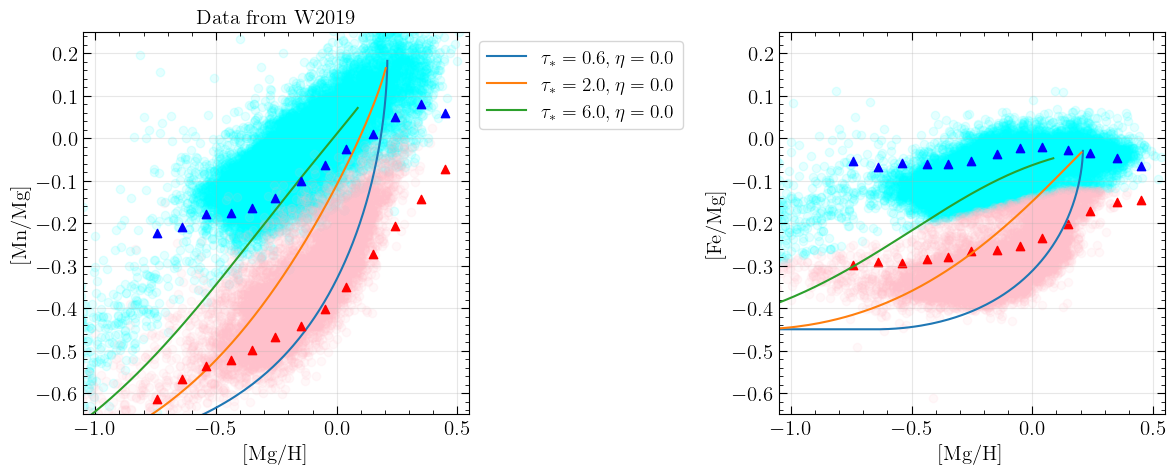

In [4]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

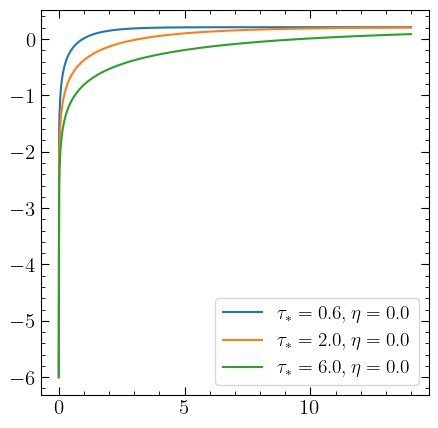

In [5]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

eta_1 = 0
tau_stars_1 = [0.6, 2, 6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = eta_1, tau_star=tau_stars_1[i]))

plt.figure(figsize=(5,5))

for i in range(len(gals_1)):
    plt.plot(gals_1[i].t, gals_1[i].O_H, label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend()
plt.show()

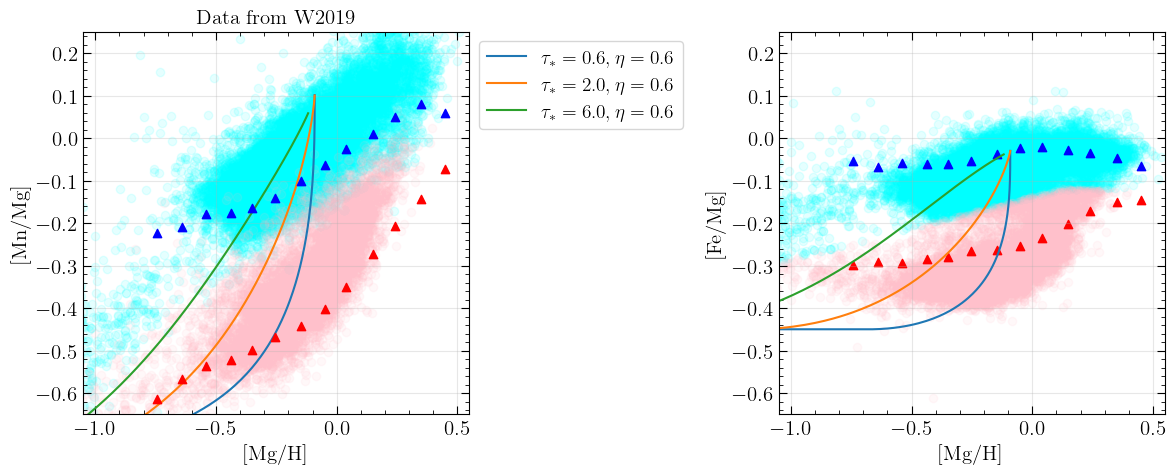

In [6]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

eta_1 = 0.6
tau_stars_1 = [0.6, 2, 6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = eta_1, tau_star=tau_stars_1[i]))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

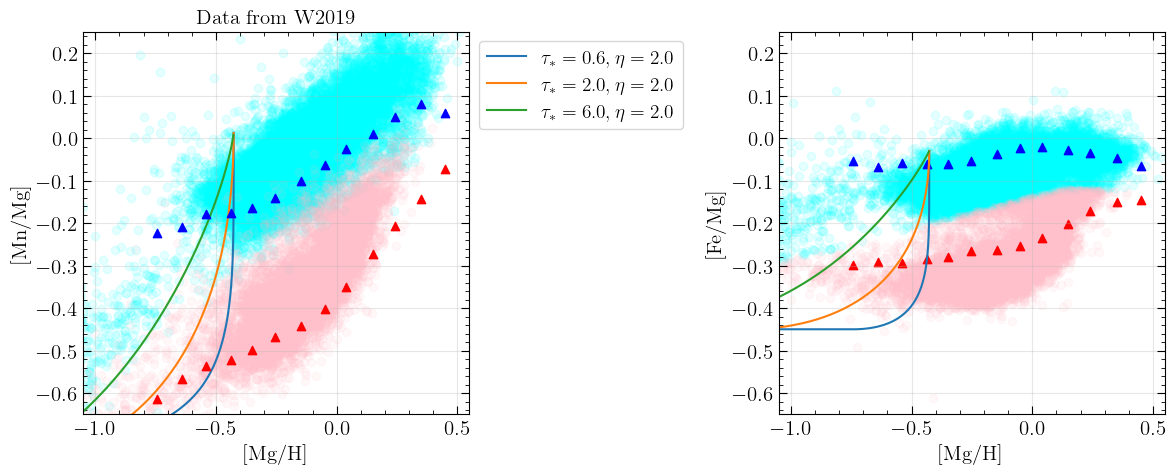

In [7]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

eta_1 = 2.0
tau_stars_1 = [0.6, 2, 6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = eta_1, tau_star=tau_stars_1[i]))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

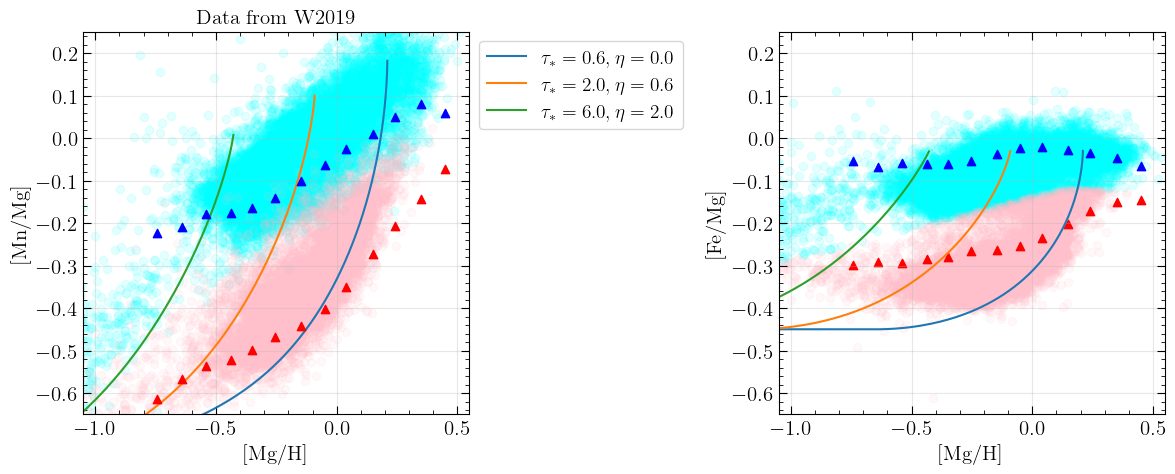

In [8]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

etas_1 = [0, 0.6, 2]
tau_stars_1 = [0.6, 2, 6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = etas_1[i], tau_star=tau_stars_1[i]))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

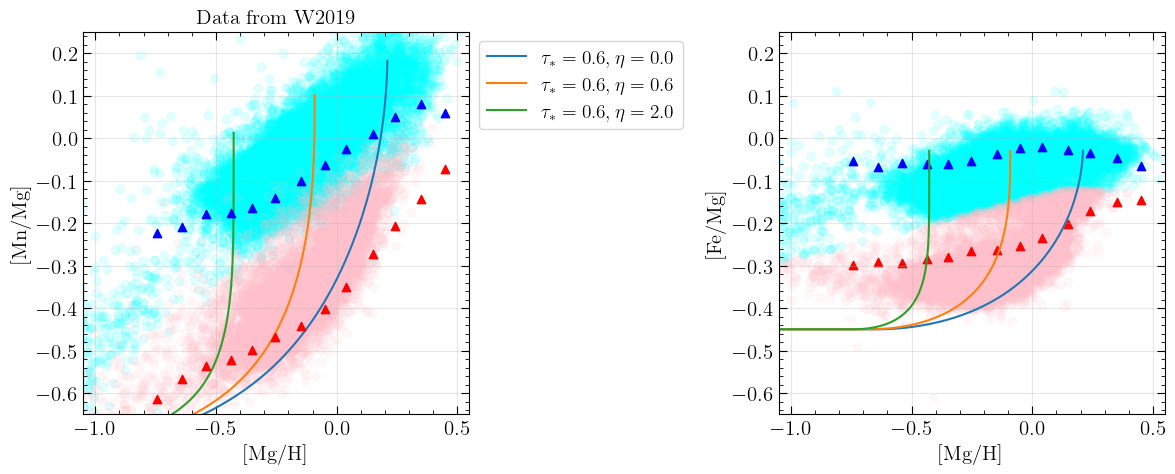

In [9]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

etas_1 = [0, 0.6, 2]
tau_stars_1 = [0.6, 0.6, 0.6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = etas_1[i], tau_star=tau_stars_1[i]))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

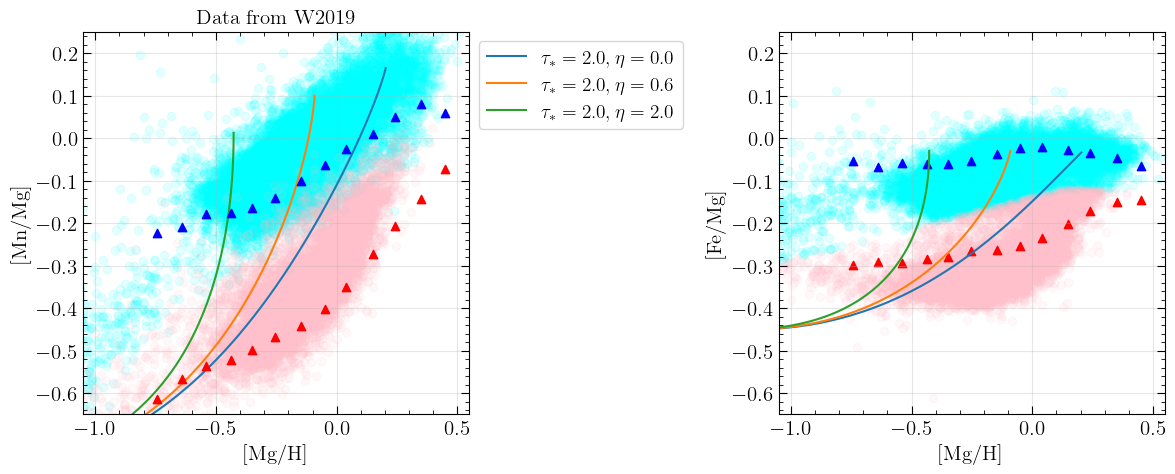

In [10]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

etas_1 = [0, 0.6, 2]
tau_stars_1 = [2, 2, 2]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = etas_1[i], tau_star=tau_stars_1[i]))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

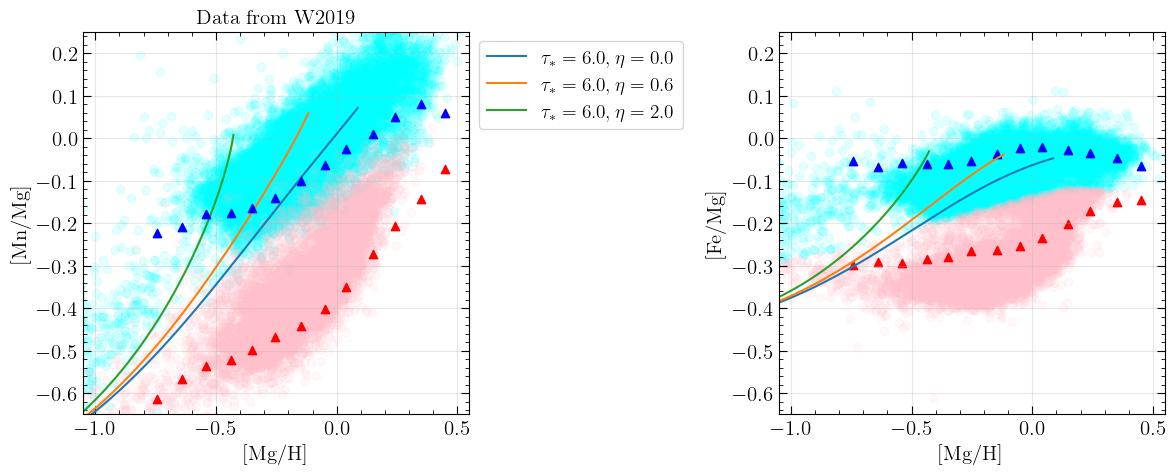

In [11]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
m_g_array_const = np.ones(len(t_array))

gals_1 = []

etas_1 = [0, 0.6, 2]
tau_stars_1 = [6, 6, 6]

for i in range(len(tau_stars_1)):
    gals_1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = etas_1[i], tau_star=tau_stars_1[i]))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Mn_O[1:], label = rf'$\tau_* = {gals_1[i].tau_star_arr[0]} , \eta = {gals_1[i].eta_arr[0]} $')


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan')
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink')
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

for i in range(len(tau_stars_1)):
    plt.plot(gals_1[i].O_H[1:], gals_1[i].Fe_O[1:])


plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()